# ĐỒ ÁN 3: TÁI HIỆN THỰC NGHIỆM CHÍNH (MAIN EXPERIMENTS)
**Mục tiêu:** Tái hiện chính xác các Hình 5.1, 5.2 và 5.3 trong bài báo gốc để chứng minh tính bền vững của thuật toán Spectral Clustering dưới tác động của nhiễu Local Differential Privacy (LDP).

In [30]:
# ==========================================
# CÀI ĐẶT MÔI TRƯỜNG KAGGLE / GOOGLE COLAB
# ==========================================
import os

# Clone repo nếu chạy trên Kaggle
# !git clone https://github.com/FIT-SE23/DataMining-Lab3.git

# Di chuyển về thư mục gốc
# %cd /kaggle/working/DataMining-Lab3

import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Thêm đường dẫn hiện tại vào sys.path để Python tìm thấy thư mục 'src'
# sys.path.append('.') 
sys.path.append('..') 

from src.utils import load_and_preprocess_graph, apply_edge_flipping
from src.model import spectral_clustering
from src.metrics import symmetric_difference_distance

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

## 1. Load dữ liệu và tính mốc chuẩn (Baseline)
Sử dụng 2 dataset `0.edges` (n=120) và `1684.edges` (n=574) sau khi đã được tiền xử lý (gọt tỉa) giống hệt bài báo.

In [22]:
print("Đang tải và tiền xử lý dữ liệu...")
G_0 = load_and_preprocess_graph('../data/0.edges')
G_1684 = load_and_preprocess_graph('../data/1684.edges')

print(f"Đồ thị 0.edges: {G_0.number_of_nodes()} nodes")
print(f"Đồ thị 1684.edges: {G_1684.number_of_nodes()} nodes")

c1_0_true, c2_0_true, _ = spectral_clustering(G_0)
c1_1684_true, c2_1684_true, _ = spectral_clustering(G_1684)

Đang tải và tiền xử lý dữ liệu...
Đồ thị 0.edges: 136 nodes
Đồ thị 1684.edges: 619 nodes


## 2. Tái hiện Figure 5.1: Vùng an toàn (Nhiễu rất nhỏ)
Kiểm tra với xác suất lật cạnh $p$ cực nhỏ (từ 0.0 đến 0.005) để chứng minh thuật toán gần như không có sai số.

Đang chạy thực nghiệm Figure 5.1...


100%|██████████| 50/50 [3:12:23<00:00, 230.88s/it]


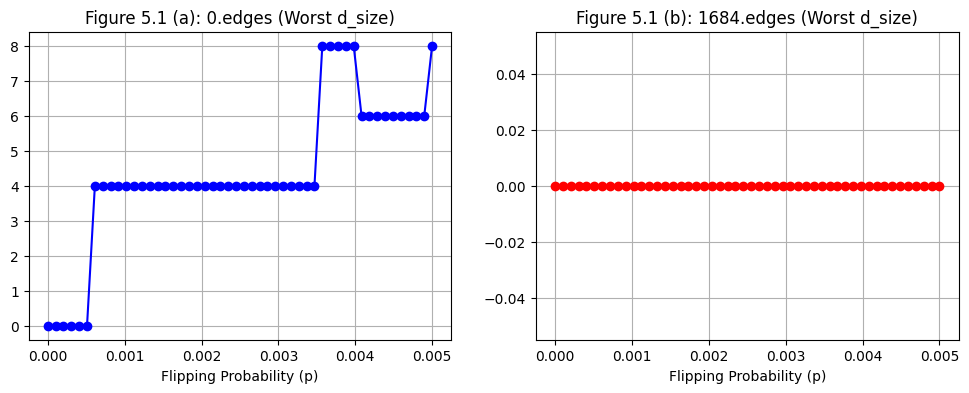

In [3]:
p_small = np.linspace(0, 0.005, 50)
num_trials_small = 100

worst_0_small = []
worst_1684_small = []

print("Đang chạy thực nghiệm Figure 5.1...")
for p in tqdm(p_small):
    err_0, err_1684 = [], []
    for trial in range(num_trials_small):
        G0_noisy = apply_edge_flipping(G_0, p, seed=GLOBAL_SEED)
        c1_0, c2_0, _ = spectral_clustering(G0_noisy)
        err_0.append(symmetric_difference_distance(c1_0_true, c2_0_true, c1_0, c2_0))

        G1684_noisy = apply_edge_flipping(G_1684, p, seed=GLOBAL_SEED)
        c1_1684, c2_1684, _ = spectral_clustering(G1684_noisy)
        err_1684.append(symmetric_difference_distance(c1_1684_true, c2_1684_true, c1_1684, c2_1684))
        
    worst_0_small.append(np.max(err_0))
    worst_1684_small.append(np.max(err_1684))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(p_small, worst_0_small, 'o-', color='blue')
axs[0].set_title("Figure 5.1 (a): 0.edges (Worst d_size)")
axs[0].set_xlabel('Flipping Probability (p)')
axs[0].grid(True)

axs[1].plot(p_small, worst_1684_small, 'o-', color='red')
axs[1].set_title("Figure 5.1 (b): 1684.edges (Worst d_size)")
axs[1].set_xlabel('Flipping Probability (p)')
axs[1].grid(True)
plt.show()

## 3. Tái hiện Figure 5.2 và 5.3: Tìm điểm đứt gãy (Nhiễu lớn)
Tăng xác suất $p$ lên mức cao để tìm giới hạn chịu đựng của thuật toán. Chúng ta sẽ lưu lại cả `Worst-case` (cho Figure 5.2) và `Average` (cho Figure 5.3) trong cùng một vòng lặp.

In [4]:
# Xác suất khác nhau cho 2 đồ thị theo đúng bài báo
p_large_0 = np.linspace(0, 0.25, 50)
p_large_1684 = np.linspace(0, 0.05, 50)

num_trials_large = 100

res_0 = {'worst': [], 'avg': []}
res_1684 = {'worst': [], 'avg': []}

print("Đang chạy thực nghiệm Figure 5.2 & 5.3 cho 0.edges...")
for p in tqdm(p_large_0):
    err = []
    for trial in range(num_trials_large):
        G_noisy = apply_edge_flipping(G_0, p, seed=GLOBAL_SEED)
        c1, c2, _ = spectral_clustering(G_noisy)
        err.append(symmetric_difference_distance(c1_0_true, c2_0_true, c1, c2))
    res_0['worst'].append(np.max(err))
    res_0['avg'].append(np.mean(err))

print("Đang chạy thực nghiệm Figure 5.2 & 5.3 cho 1684.edges...")
for p in tqdm(p_large_1684):
    err = []
    for trial in range(num_trials_large):
        G_noisy = apply_edge_flipping(G_1684, p, seed=GLOBAL_SEED)
        c1, c2, _ = spectral_clustering(G_noisy)
        err.append(symmetric_difference_distance(c1_1684_true, c2_1684_true, c1, c2))
    res_1684['worst'].append(np.max(err))
    res_1684['avg'].append(np.mean(err))

Đang chạy thực nghiệm Figure 5.2 & 5.3 cho 0.edges...


100%|██████████| 50/50 [10:33<00:00, 12.66s/it]


Đang chạy thực nghiệm Figure 5.2 & 5.3 cho 1684.edges...


100%|██████████| 50/50 [3:37:27<00:00, 260.95s/it]


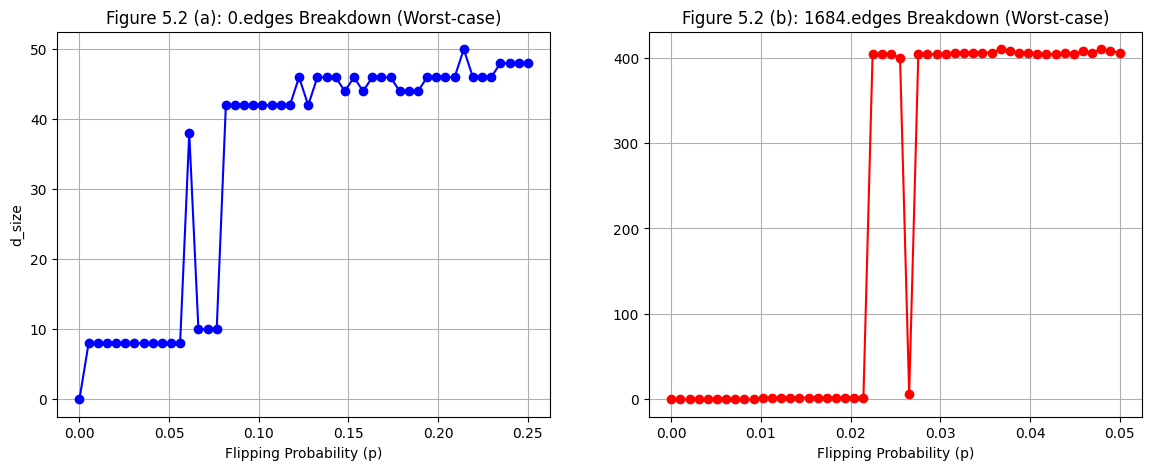

In [5]:
# Tái hiện Figure 5.2: Worst-case Breakdown
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(p_large_0, res_0['worst'], 'o-', color='blue')
axs[0].set_title("Figure 5.2 (a): 0.edges Breakdown (Worst-case)")
axs[0].set_xlabel('Flipping Probability (p)')
axs[0].set_ylabel('d_size')
axs[0].grid(True)

axs[1].plot(p_large_1684, res_1684['worst'], 'o-', color='red')
axs[1].set_title("Figure 5.2 (b): 1684.edges Breakdown (Worst-case)")
axs[1].set_xlabel('Flipping Probability (p)')
axs[1].grid(True)

plt.show()

- Thực nghiệm Facebook0 cho các seed khác nhau

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [11:33<00:00, 13.87s/it]


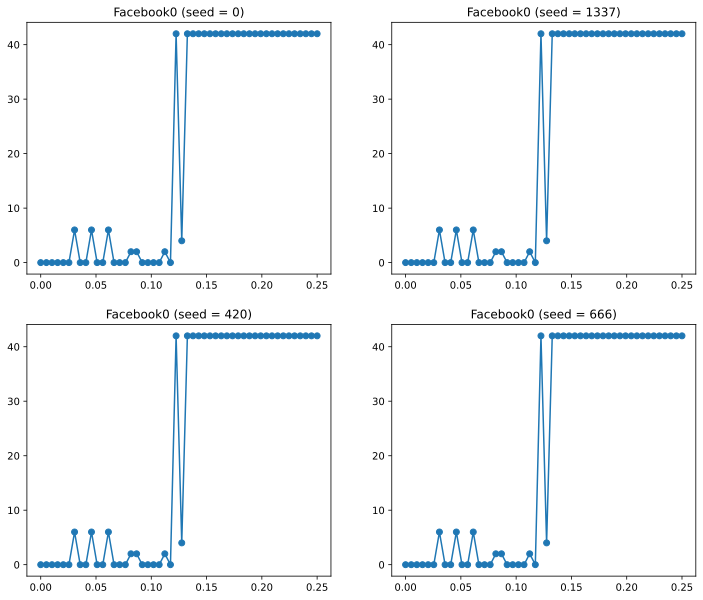

In [24]:
plt.figure(figsize=(12, 10))
p_large_0 = np.linspace(0, 0.25, 50)

worst_large = [0] * 4
avg_large = [0] * 4

for i, seed in enumerate([0, 1337, 420, 666]):
    random.seed(seed)
    np.random.seed(seed)

    worst_large[i], avg_large[i] = run_experiment(G0, p_large_0, num_trials=100)

    plt.subplot(2, 2, i + 1)
    plt.plot(p_large_0, avg_large[i], 'o-')
    plt.title(f"Facebook0 (seed = {seed})")
plt.savefig("Figure 5.2 seeds.svg", format="svg")
plt.show()

In [26]:
p_large_1684 = np.linspace(0, 0.10, 20)

num_trials_large = 100
res_1684 = {'worst': [], 'avg': []}

print("Đang chạy thực nghiệm Figure 5.3 cho 1684.edges...")
for p in tqdm(p_large_1684):
    err = []
    for trial in range(num_trials_large):
        G_noisy = apply_edge_flipping(G_1684, p, seed=GLOBAL_SEED)
        c1, c2, _ = spectral_clustering(G_noisy)
        err.append(symmetric_difference_distance(c1_1684_true, c2_1684_true, c1, c2))
    res_1684['worst'].append(np.max(err))
    res_1684['avg'].append(np.mean(err))

Đang chạy thực nghiệm Figure 5.3 cho 1684.edges...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [2:24:49<00:00, 434.49s/it]


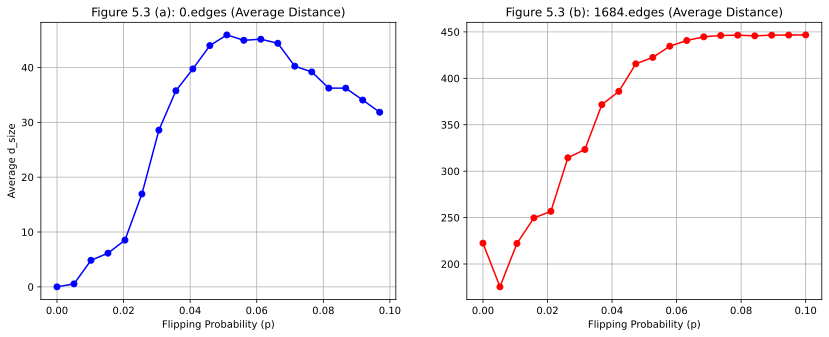

In [29]:
# Tái hiện Figure 5.3: Average Distances
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Bài báo chỉ tập trung vào 20 điểm đầu tiên cho Figure 5.3a (p < 0.10)
axs[0].plot(p_large_0[:20], res_0['avg'][:20], 'o-', color='blue')
axs[0].set_title("Figure 5.3 (a): 0.edges (Average Distance)")
axs[0].set_xlabel('Flipping Probability (p)')
axs[0].set_ylabel('Average d_size')
axs[0].grid(True)

axs[1].plot(p_large_1684, res_1684['avg'], 'o-', color='red')
axs[1].set_title("Figure 5.3 (b): 1684.edges (Average Distance)")
axs[1].set_xlabel('Flipping Probability (p)')
axs[1].grid(True)
plt.savefig("Figure 5.3.svg", format="svg")
plt.show()